# 02 — EDA : Analyse Exploratoire des Données
## FAERS Drug Hospitalization Dataset

**Module :** Machine Learning — Phase 1  
**Auteurs :** Amine El Biyadi / Aya Raissouni / Douae Moeniss  
**Date :** Mai 2026  
**Encadrant :** Pr. Y. EL YOUNOUSSI  

---

**Objectif :** Mener une analyse exploratoire complète du dataset FAERS constitué en Phase 1,  
identifier les variables prédictives, analyser le déséquilibre des classes,  
et produire une bonne synthèse .

**Livrables couverts :**
- Exploration univariée (histogramme, boxplot, stats descriptives, modalités rares)
- Exploration bivariée (numérique × cible, catégorielle × cible, numérique × numérique)
- Analyse spécifique du déséquilibre (ratio exact, stats séparées, features signaux)
- Synthèse finale


## 1. Imports et chargement du dataset

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

PALETTE    = ["#5A81C0", "#E298AE"]
PALETTE_CAT = sns.color_palette("deep", 12)

# ── Dataset path — adjust if needed
DATASET_PATH = "../data/dataset.csv"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : {DATASET_PATH}\n"
        "Lancez d'abord : python src/data_collection.py"
    )

df = pd.read_csv(DATASET_PATH)

NUMERIC_COLS = [
    "patient_age", "nb_drugs", "nb_reactions",
    "worst_reaction_outcome", "nb_suspect_drugs",
]
CATEGORICAL_COLS = [
    "patient_sex", "reporter_qualification", "route_of_admin",
    "country", "has_black_box_warning", "is_concomitant_present",
]
TARGET_COL = "seriousnesshospitalization"

# Cast target to int for computations, keep original for display
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)

print(f"Dataset chargé — {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")


Dataset chargé — 10,200 lignes x 12 colonnes
pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


---
## 2. Exploration univariée

### 2a. Variables numériques — Statistiques descriptives


In [3]:
desc = df[NUMERIC_COLS].describe().round(2)
desc.loc["median"] = df[NUMERIC_COLS].median().round(2)
desc.loc["skewness"] = df[NUMERIC_COLS].skew().round(2)
desc


,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs
count,6775.00,10200.00,10200.00,9538.00,10200.00
mean,81.39,3.23,2.67,4.91,1.72
std,753.78,3.86,3.13,1.77,1.54
min,0.00,1.00,1.00,1.00,1.00
25%,47.00,1.00,1.00,3.00,1.00
50%,61.00,2.00,2.00,6.00,1.00
75%,72.00,4.00,3.00,6.00,2.00
max,32193.00,88.00,60.00,6.00,32.00
median,61.00,2.00,2.00,6.00,1.00
skewness,32.85,4.59,5.93,-1.26,6.36


### 2b. Variables numériques — Histogrammes + Boxplots


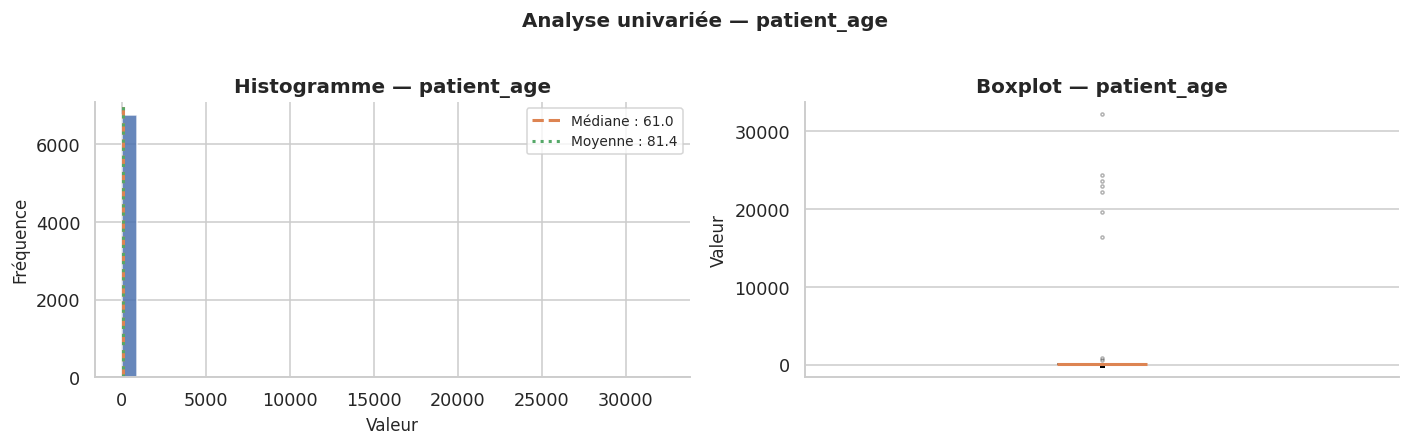

  n=6,775 | manquants=3425 | min=0.0 | max=32193.0 | skewness=32.85



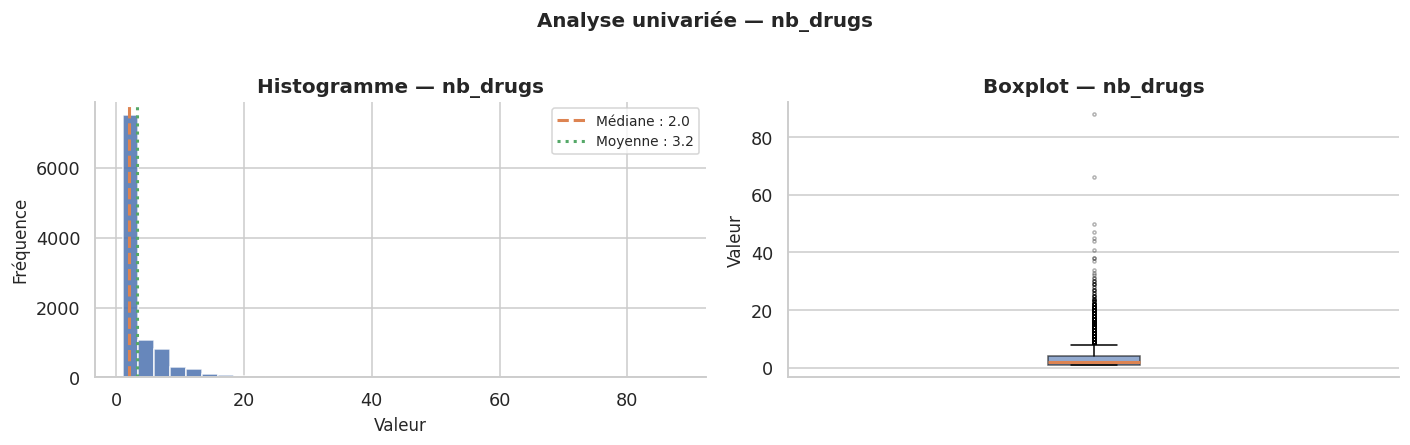

  n=10,200 | manquants=0 | min=1.0 | max=88.0 | skewness=4.59



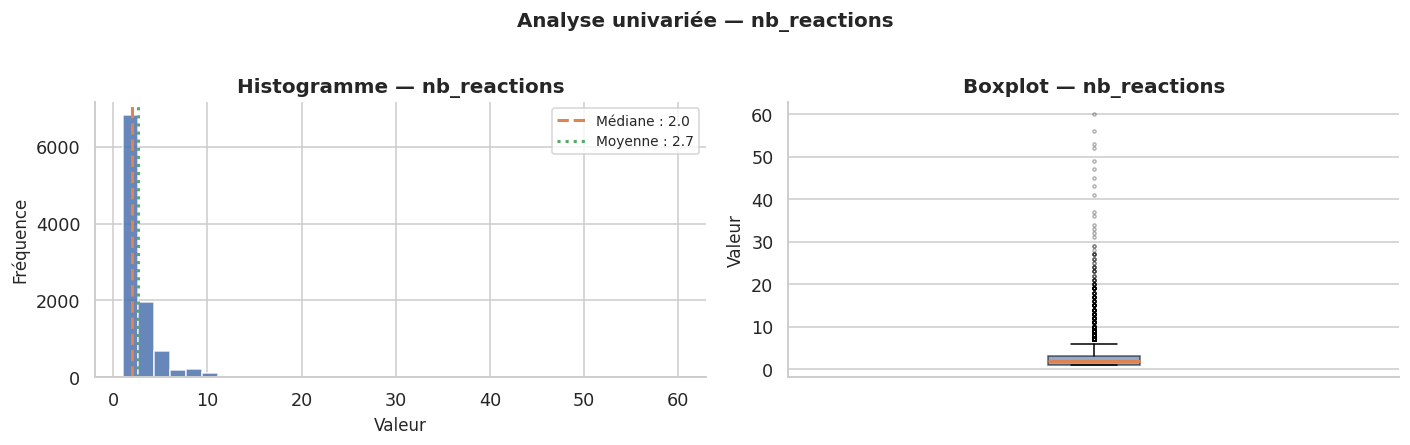

  n=10,200 | manquants=0 | min=1.0 | max=60.0 | skewness=5.93



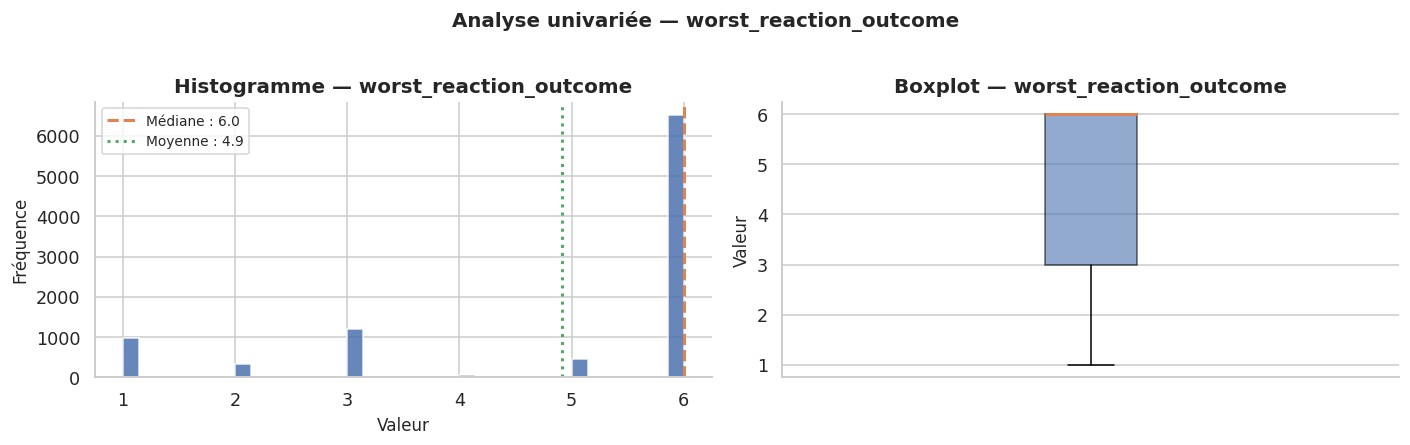

  n=9,538 | manquants=662 | min=1.0 | max=6.0 | skewness=-1.26



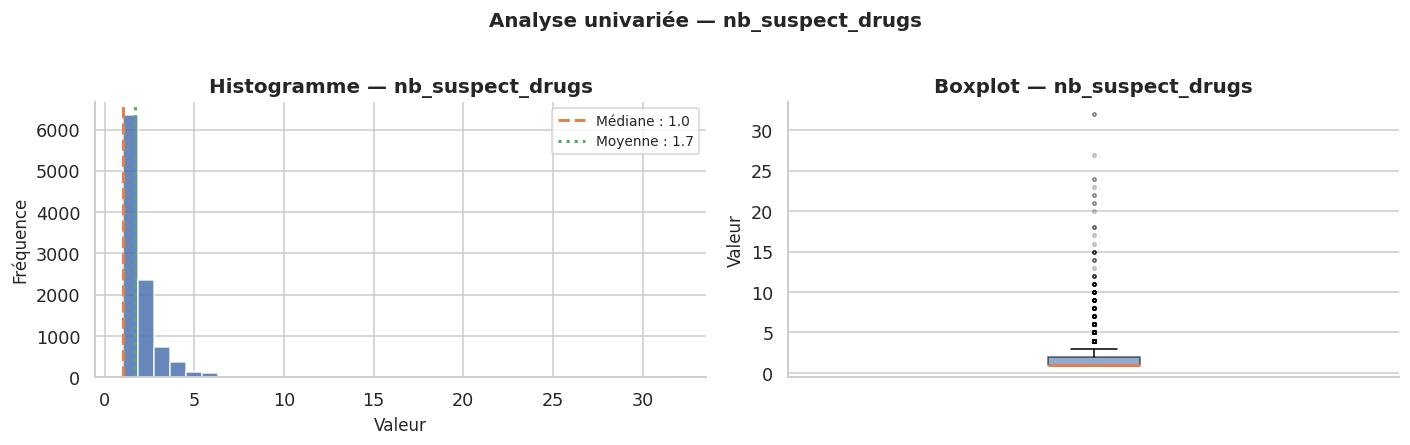

  n=10,200 | manquants=0 | min=1.0 | max=32.0 | skewness=6.36



In [4]:
for col in NUMERIC_COLS:
    data = df[col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogramme
    ax = axes[0]
    ax.hist(data, bins=35, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="#DD8452", linestyle="--", linewidth=2,
               label=f"Médiane : {data.median():.1f}")
    ax.axvline(data.mean(), color="#55A868", linestyle=":", linewidth=2,
               label=f"Moyenne : {data.mean():.1f}")
    ax.set_title(f"Histogramme — {col}")
    ax.set_xlabel("Valeur")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=9)

    # Boxplot
    ax2 = axes[1]
    ax2.boxplot(data.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="#DD8452", linewidth=2),
                flierprops=dict(marker="o", markersize=2, alpha=0.3, color="#4C72B0"))
    ax2.set_title(f"Boxplot — {col}")
    ax2.set_ylabel("Valeur")
    ax2.set_xticks([])

    plt.suptitle(f"Analyse univariée — {col}", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"  n={len(data):,} | manquants={df[col].isna().sum()} "
          f"| min={data.min():.1f} | max={data.max():.1f} "
          f"| skewness={data.skew():.2f}")
    print()


### 2c. Variables catégorielles — Fréquences et modalités rares (< 1 %)


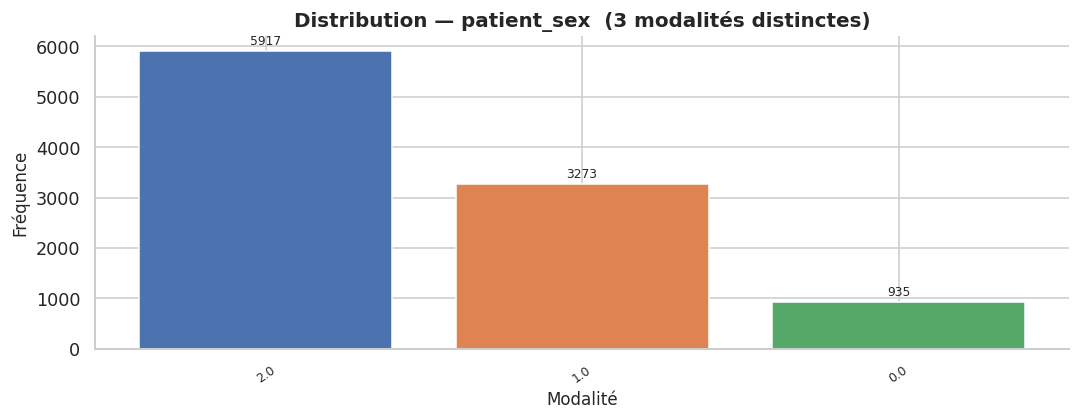

  patient_sex : 3 modalités | mode = '2.0' (58.0%)
  Aucune modalité rare détectée



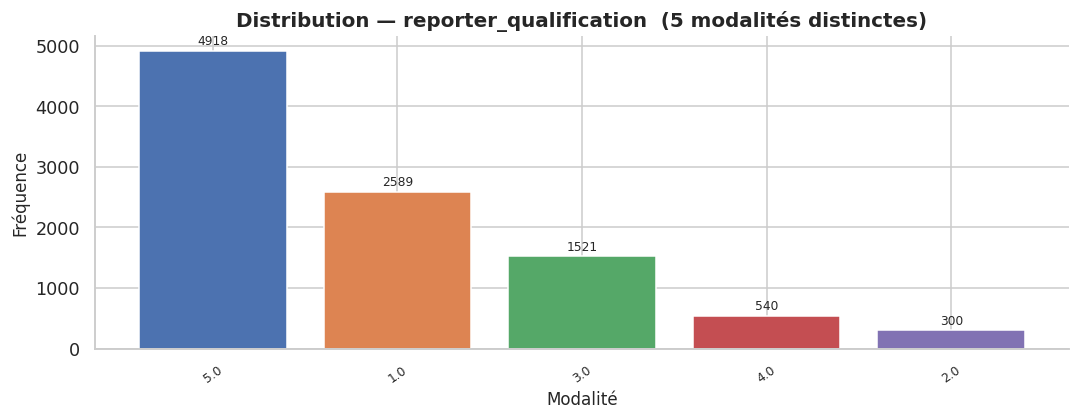

  reporter_qualification : 5 modalités | mode = '5.0' (48.2%)
  Aucune modalité rare détectée



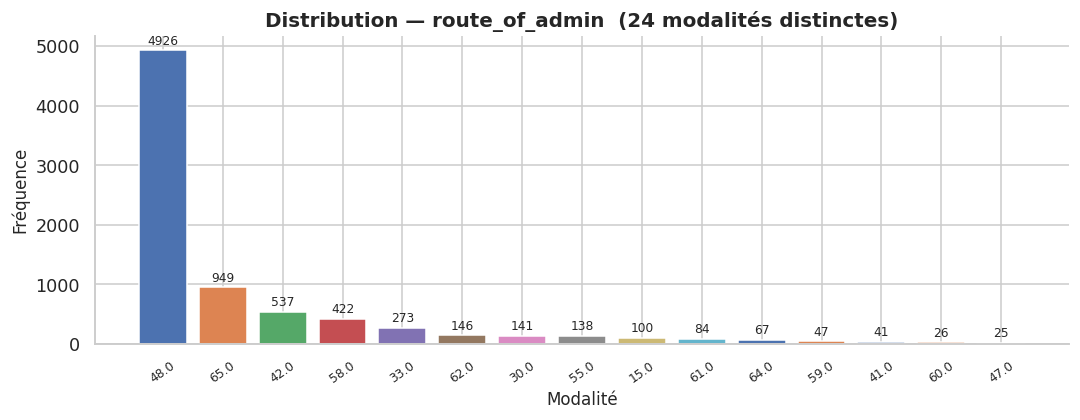

  route_of_admin : 24 modalités | mode = '48.0' (48.3%)
  Modalités rares (< 1%) : ['15.0', '61.0', '64.0', '59.0', '41.0', '60.0', '47.0', '67.0', '50.0', '45.0', '37.0', '2.0', '40.0', '31.0', '8.0', '49.0', '51.0', '4.0', '23.0', '14.0', '13.0', '43.0']  → à regrouper en 'other' en Phase 2



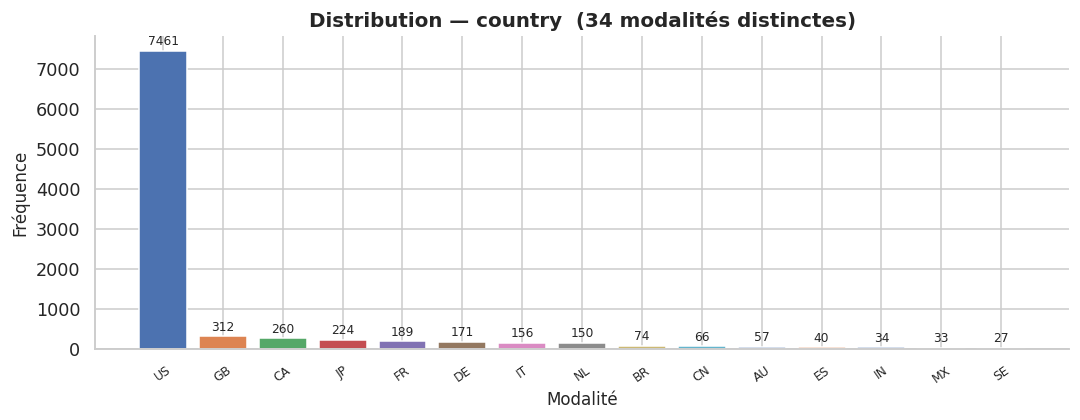

  country : 34 modalités | mode = 'US' (73.1%)
  Modalités rares (< 1%) : ['BR', 'CN', 'AU', 'ES', 'IN', 'MX', 'SE', 'TR', 'CO', 'IE', 'AR', 'BE', 'PL', 'IL', 'CH', 'KR', 'BD', 'PH', 'AT', 'CL', 'RU', 'ZA', 'PT', 'DK', 'PE', 'GR', 'TW', 'HR', 'PR', 'VE', 'HU', 'TH', 'FI', 'LB', 'CZ', 'NO', 'NZ', 'SK', 'MY', 'HK', 'EG', 'IR', 'RO', 'KE', 'ID', 'SA', 'TN', 'EC', 'BG', 'RS', 'LY', 'MA', 'UA', 'MW', 'VN', 'DZ', 'KP', 'GT', 'GW', 'UY', 'CR', 'SG', 'SI', 'LT', 'BW', 'UG', 'PA']  → à regrouper en 'other' en Phase 2



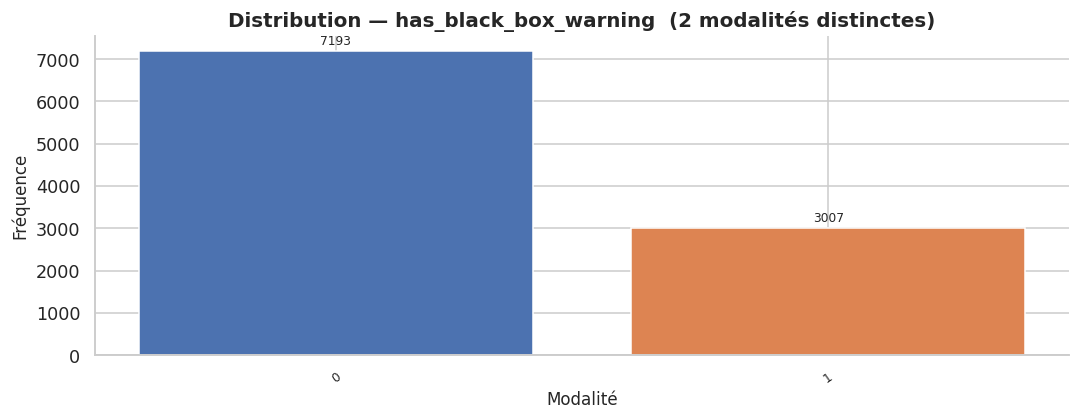

  Aucune modalité rare détectée



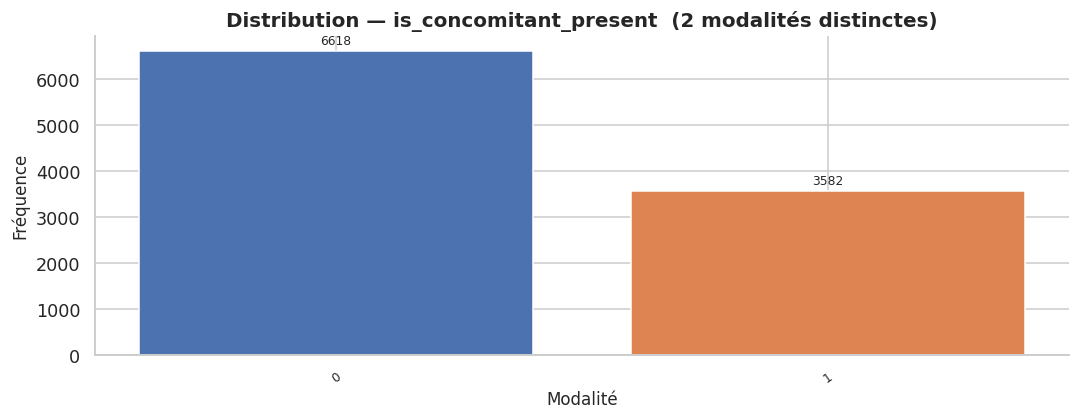

  is_concomitant_present : 2 modalités | mode = '0' (64.9%)
  Aucune modalité rare détectée



In [6]:
THRESHOLD_RARE = 0.01  # modalité rare si fréquence < 1%

for col in CATEGORICAL_COLS:
    vc = df[col].astype(str).value_counts()
    vc_pct = vc / len(df) * 100
    rare = vc_pct[vc_pct < THRESHOLD_RARE * 100]

    fig, ax = plt.subplots(figsize=(10, 4))
    top = vc.head(15)
    bars = ax.bar(top.index.astype(str), top.values,
                  color=PALETTE_CAT[:len(top)], edgecolor="white")
    ax.bar_label(bars, fontsize=8, padding=2)
    ax.set_title(f"Distribution — {col}  ({vc.nunique()} modalités distinctes)")
    ax.set_xlabel("Modalité")
    ax.set_ylabel("Fréquence")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    plt.tight_layout()
    plt.show()

    print(f"  {col} : {vc.nunique()} modalités | "
          f"mode = '{vc.index[0]}' ({vc_pct.iloc[0]:.1f}%)")
    if not rare.empty:
        print(f"  Modalités rares (< 1%) : {list(rare.index)}  → à regrouper en 'other' en Phase 2")
    else:
        print(f"  Aucune modalité rare détectée")
    print()


---
## 3. Exploration bivariée

### 3a. Numérique × Cible — Boxplots par classe


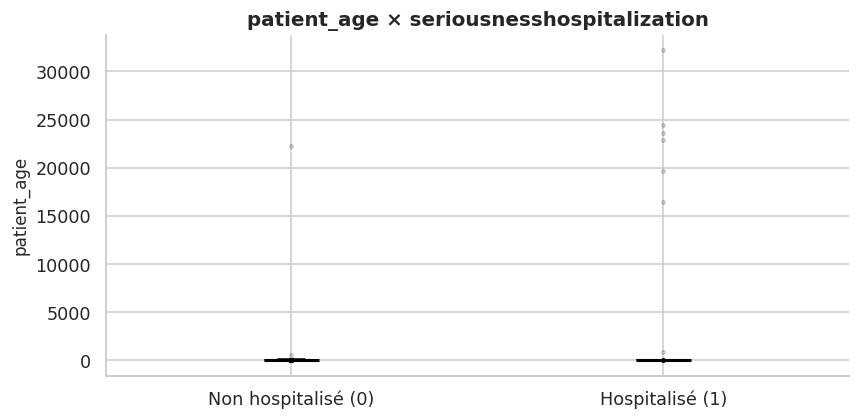

  patient_age | médiane classe 0 = 61.00 | médiane classe 1 = 60.00 | Mann-Whitney p = 0.2646 →  Non significatif



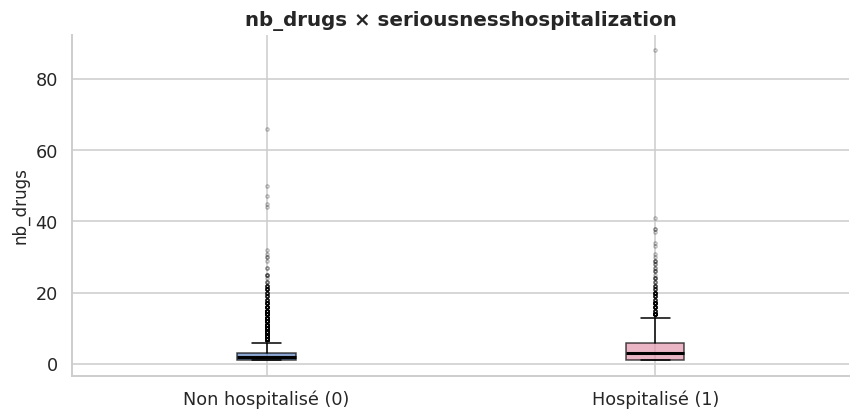

  nb_drugs | médiane classe 0 = 2.00 | médiane classe 1 = 3.00 | Mann-Whitney p = 0.0000 →  Significatif (p < 0.05)



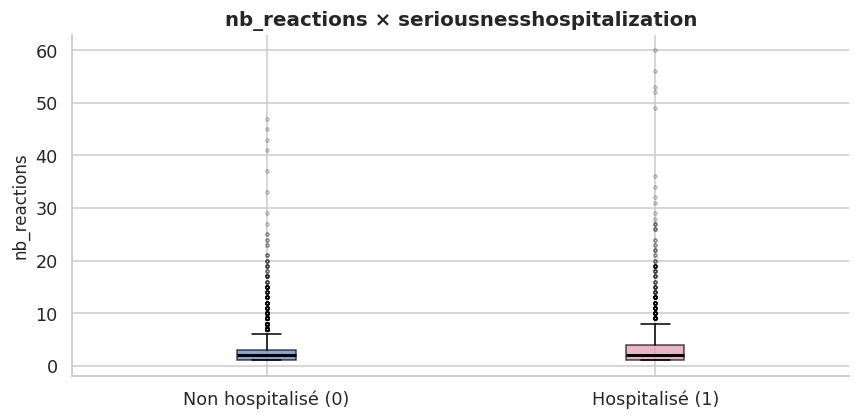

  nb_reactions | médiane classe 0 = 2.00 | médiane classe 1 = 2.00 | Mann-Whitney p = 0.0000 →  Significatif (p < 0.05)



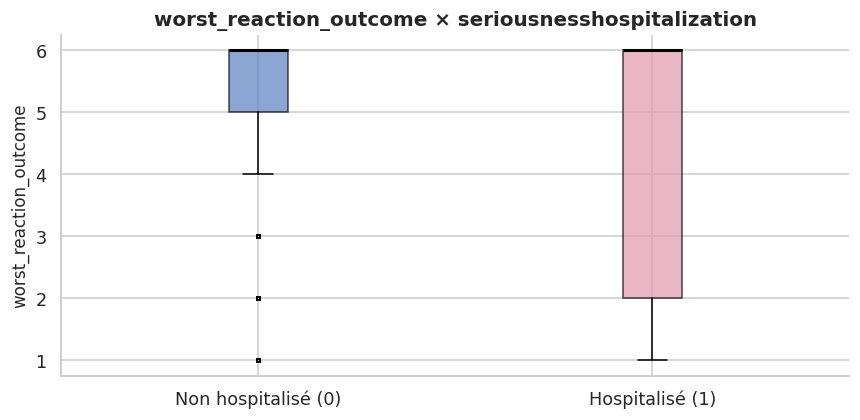

  worst_reaction_outcome | médiane classe 0 = 6.00 | médiane classe 1 = 6.00 | Mann-Whitney p = 0.0000 →  Significatif (p < 0.05)



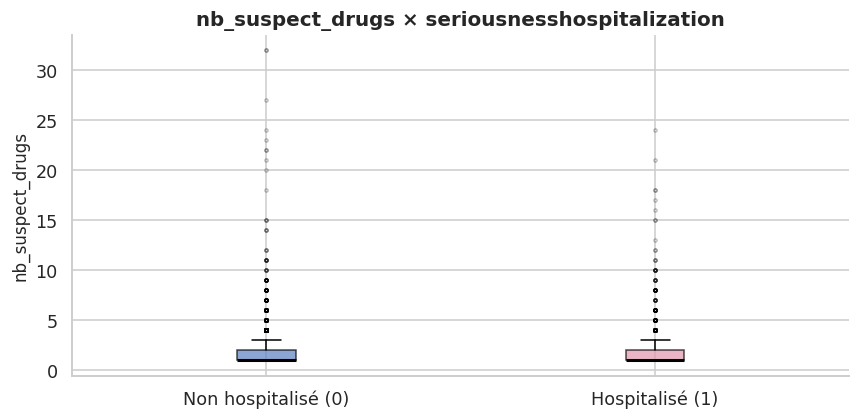

  nb_suspect_drugs | médiane classe 0 = 1.00 | médiane classe 1 = 1.00 | Mann-Whitney p = 0.0000 →  Significatif (p < 0.05)



In [7]:
for col in NUMERIC_COLS:
    data_0 = df[df[TARGET_COL] == 0][col].dropna()
    data_1 = df[df[TARGET_COL] == 1][col].dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    bp = ax.boxplot(
        [data_0, data_1],
        labels=["Non hospitalisé (0)", "Hospitalisé (1)"],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(linewidth=2, color="black"),
        flierprops=dict(marker="o", markersize=2, alpha=0.25),
    )
    bp["boxes"][0].set_facecolor(PALETTE[0])
    bp["boxes"][1].set_facecolor(PALETTE[1])

    ax.set_title(f"{col} × seriousnesshospitalization")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

    # Test de Mann-Whitney (non-paramétrique, adapté aux distributions asymétriques)
    stat, pval = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
    sig = " Significatif (p < 0.05)" if pval < 0.05 else " Non significatif"
    print(f"  {col} | médiane classe 0 = {data_0.median():.2f} | "
          f"médiane classe 1 = {data_1.median():.2f} | "
          f"Mann-Whitney p = {pval:.4f} → {sig}")
    print()


### 3b. Catégorielle × Cible — Taux de classe positive par modalité


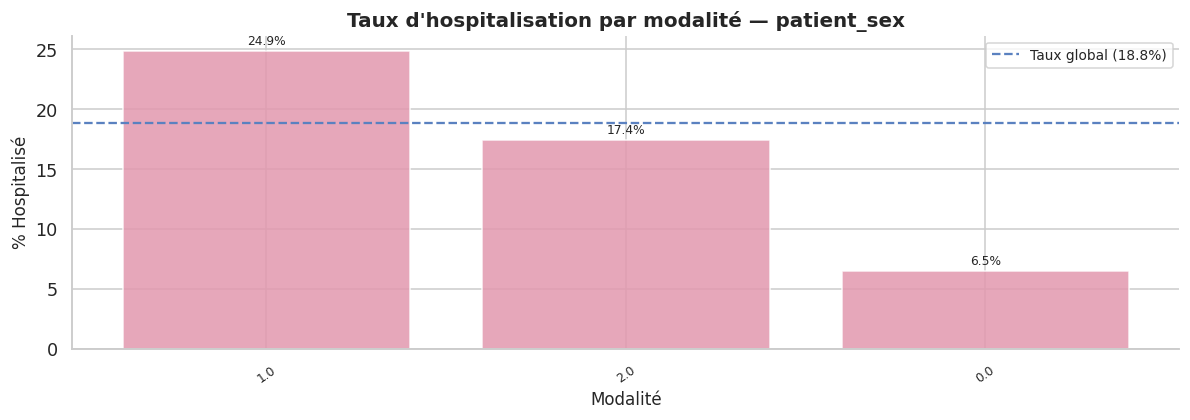

  patient_sex — tableau croisé (top 10) :
             Non hospitalisé (%)  Hospitalisé (%)
patient_sex                                      
1.0                         75.1             24.9
2.0                         82.6             17.4
0.0                         93.5              6.5



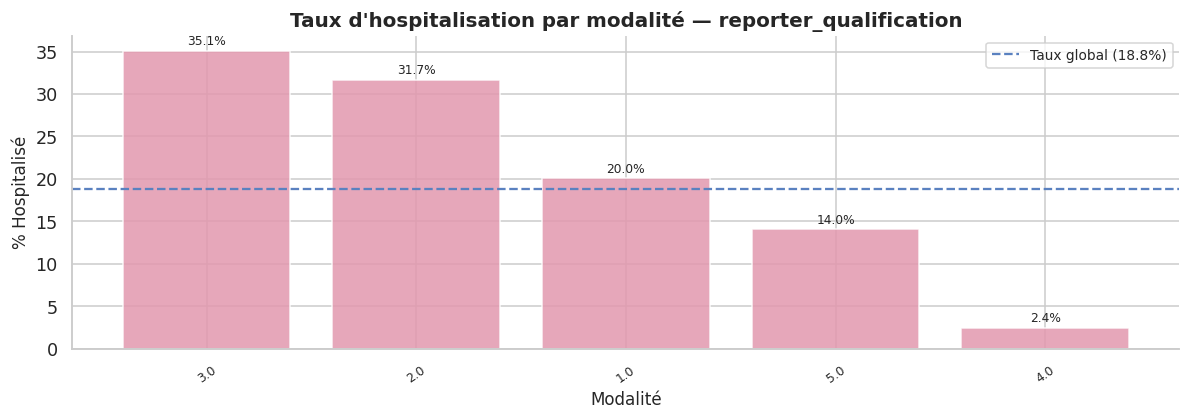

  reporter_qualification — tableau croisé (top 10) :
                        Non hospitalisé (%)  Hospitalisé (%)
reporter_qualification                                      
3.0                                    64.9             35.1
2.0                                    68.3             31.7
1.0                                    80.0             20.0
5.0                                    86.0             14.0
4.0                                    97.6              2.4



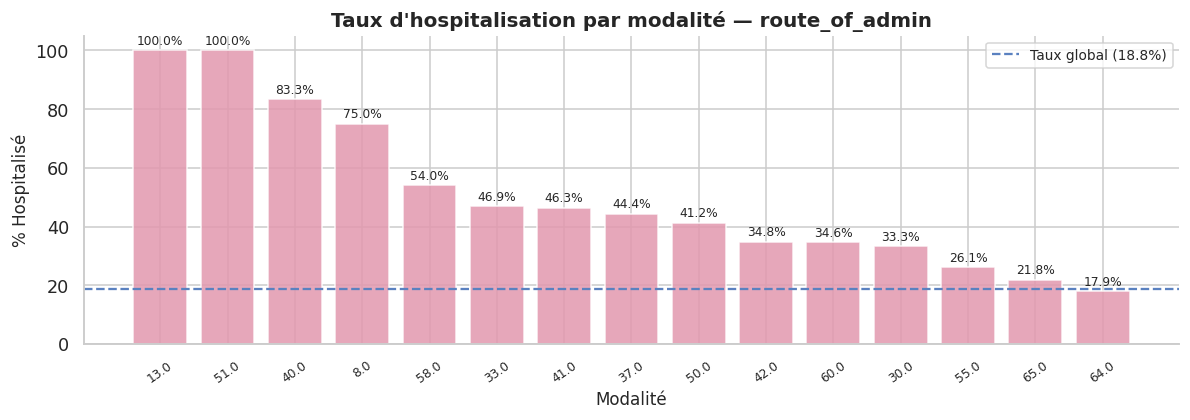

  route_of_admin — tableau croisé (top 10) :
                Non hospitalisé (%)  Hospitalisé (%)
route_of_admin                                      
13.0                            0.0            100.0
51.0                            0.0            100.0
40.0                           16.7             83.3
8.0                            25.0             75.0
58.0                           46.0             54.0
33.0                           53.1             46.9
41.0                           53.7             46.3
37.0                           55.6             44.4
50.0                           58.8             41.2
42.0                           65.2             34.8



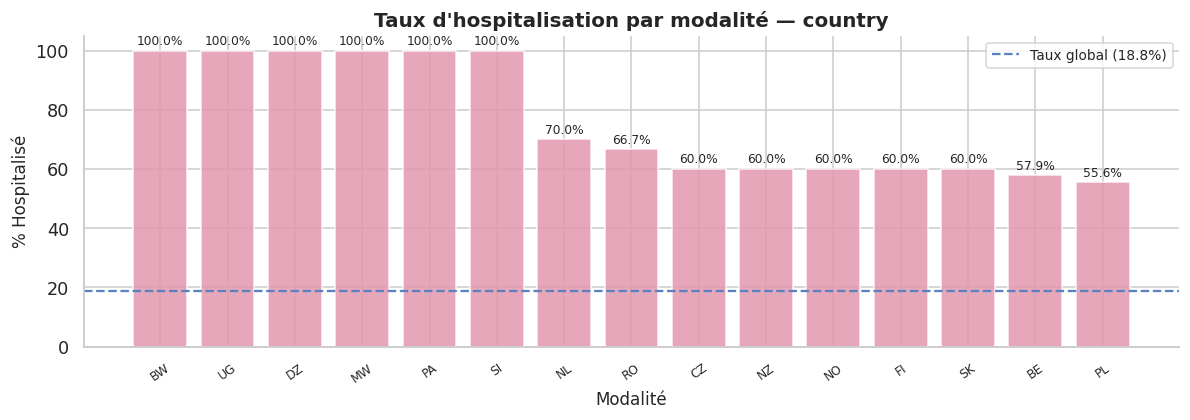

  country — tableau croisé (top 10) :
         Non hospitalisé (%)  Hospitalisé (%)
country                                      
BW                       0.0            100.0
UG                       0.0            100.0
DZ                       0.0            100.0
MW                       0.0            100.0
PA                       0.0            100.0
SI                       0.0            100.0
NL                      30.0             70.0
RO                      33.3             66.7
CZ                      40.0             60.0
NZ                      40.0             60.0



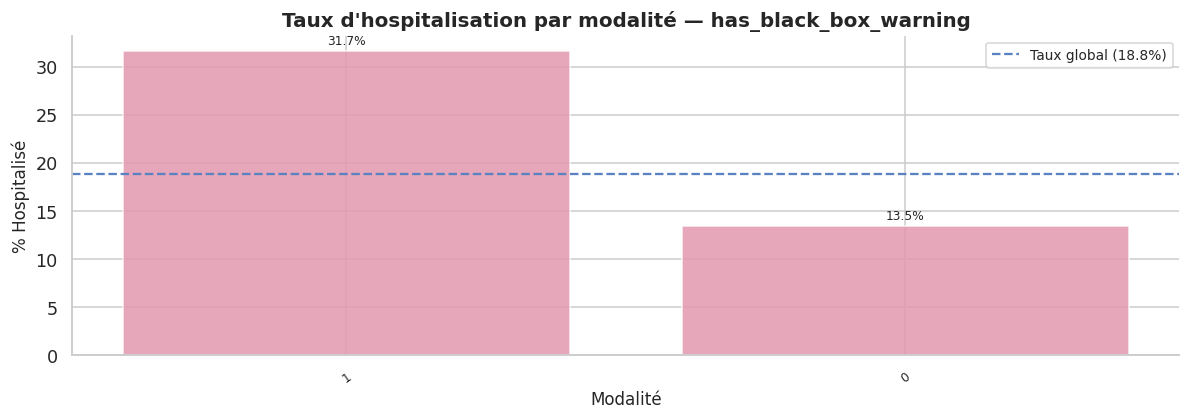

  has_black_box_warning — tableau croisé (top 10) :
                       Non hospitalisé (%)  Hospitalisé (%)
has_black_box_warning                                      
1                                     68.3             31.7
0                                     86.5             13.5



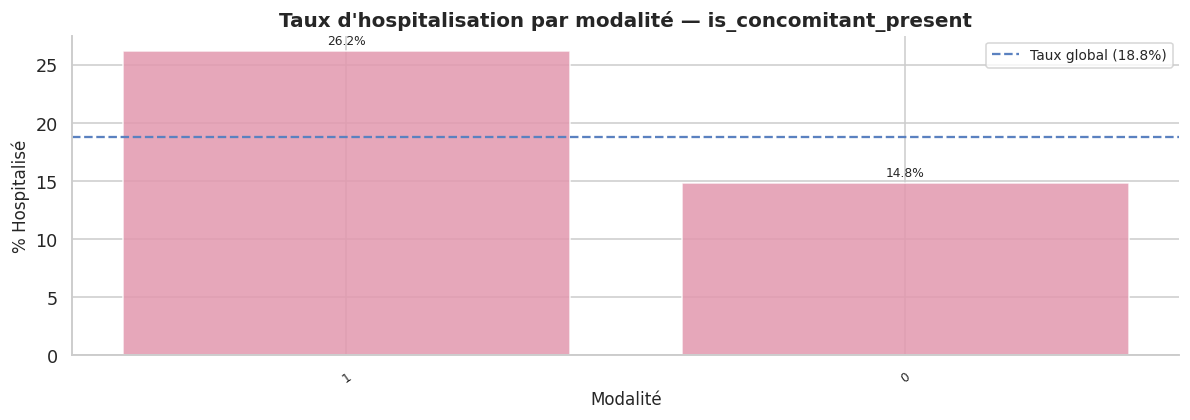

  is_concomitant_present — tableau croisé (top 10) :
                        Non hospitalisé (%)  Hospitalisé (%)
is_concomitant_present                                      
1                                      73.8             26.2
0                                      85.2             14.8



In [8]:
for col in CATEGORICAL_COLS:
    ct = pd.crosstab(df[col].astype(str), df[TARGET_COL],
                     normalize="index") * 100
    ct.columns = ["Non hospitalisé (%)", "Hospitalisé (%)"]
    ct = ct.sort_values("Hospitalisé (%)", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(11, 4))
    bars = ax.bar(ct.index, ct["Hospitalisé (%)"],
                  color=PALETTE[1], edgecolor="white", alpha=0.85)
    ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
    ax.axhline(df[TARGET_COL].mean() * 100, color=PALETTE[0],
               linestyle="--", linewidth=1.5,
               label=f"Taux global ({df[TARGET_COL].mean()*100:.1f}%)")
    ax.set_title(f"Taux d'hospitalisation par modalité — {col}")
    ax.set_xlabel("Modalité")
    ax.set_ylabel("% Hospitalisé")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    plt.tight_layout()
    plt.show()

    print(f"  {col} — tableau croisé (top 10) :")
    print(ct.head(10).round(1).to_string())
    print()


### 3c. Numérique × Numérique — Matrice de corrélation


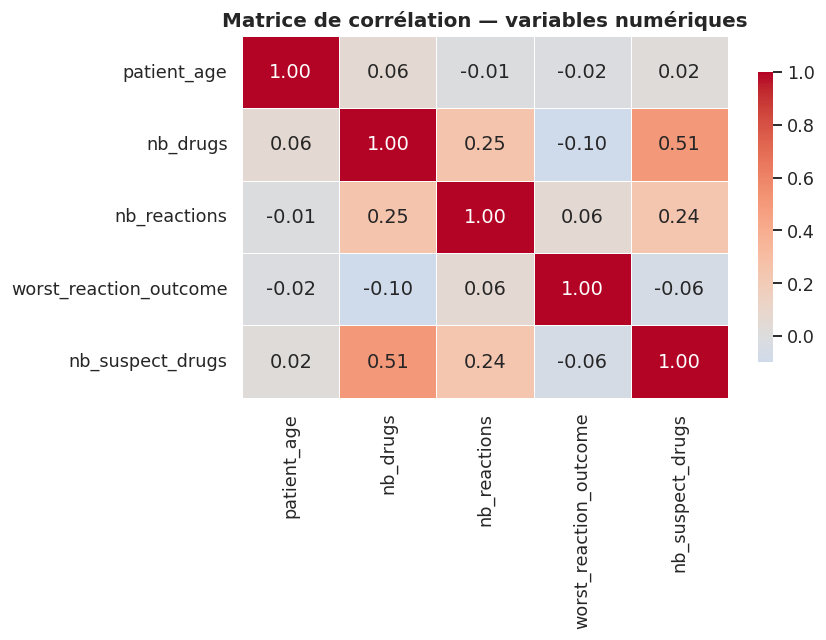

Paires fortement corrélées (|r| > 0.7) :
  Aucune paire fortement corrélée détectée (seuil |r| > 0.7)


In [9]:
corr_df = df[NUMERIC_COLS].copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()

# Identifier les paires fortement corrélées (|r| > 0.7)
print("Paires fortement corrélées (|r| > 0.7) :")
found = False
for i in range(len(NUMERIC_COLS)):
    for j in range(i+1, len(NUMERIC_COLS)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {NUMERIC_COLS[i]} × {NUMERIC_COLS[j]} : r = {r:.3f} ")
            found = True
if not found:
    print("  Aucune paire fortement corrélée détectée (seuil |r| > 0.7)")


---
## 4. Analyse spécifique du déséquilibre 

### 4a. Ratio exact des classes


In [11]:
counts = df[TARGET_COL].value_counts().sort_index()
ratios = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

print("── Ratio exact des classes ───────────────────────────────")
print(f"  Classe 0 (non hospitalisé) : {counts[0]:>6}  ({ratios[0]:.2f}%)")
print(f"  Classe 1 (hospitalisé)     : {counts[1]:>6}  ({ratios[1]:.2f}%)")
print(f"  Total                      : {len(df):>6}")
print()
print(f"  Ratio déséquilibre : 1 cas positif pour {counts[0]/counts[1]:.0f} négatifs")

constraint_ok = 0.05 <= ratios[1]/100 <= 0.25
print(f"  Contrainte 5%-25%  : {' Respectée' if constraint_ok else ' Non respectée'}")


── Ratio exact des classes ───────────────────────────────
  Classe 0 (non hospitalisé) :   8279  (81.17%)
  Classe 1 (hospitalisé)     :   1921  (18.83%)
  Total                      :  10200

  Ratio déséquilibre : 1 cas positif pour 4 négatifs
  Contrainte 5%-25%  :  Respectée


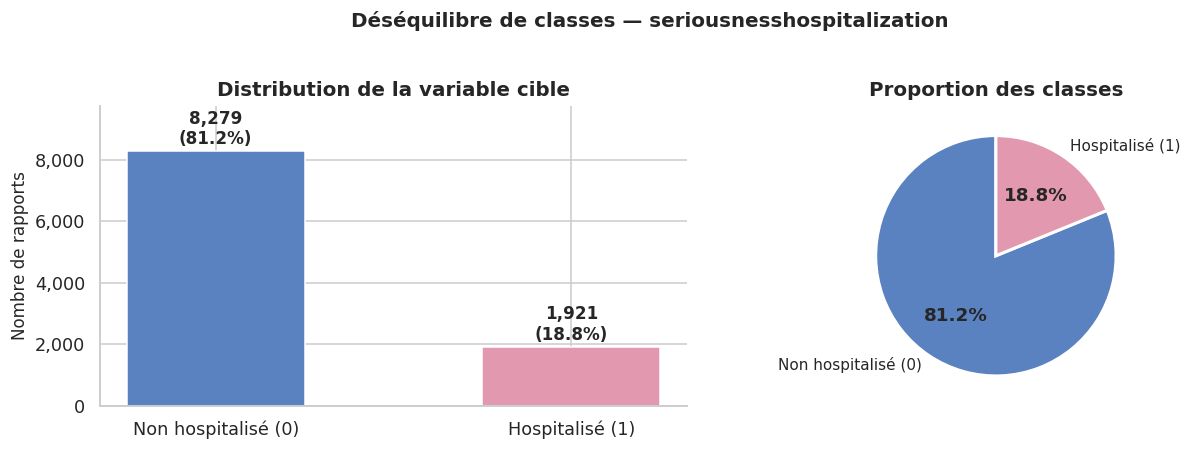

In [12]:
labels = ["Non hospitalisé (0)", "Hospitalisé (1)"]
values = [counts[0], counts[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(labels, values, color=PALETTE, edgecolor="white", width=0.5)
for bar, val, ratio in zip(bars, values, [ratios[0], ratios[1]]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values)*0.012,
            f"{val:,}\n({ratio:.1f}%)",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre de rapports")
ax.set_ylim(0, max(values)*1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    values, labels=labels, colors=PALETTE, autopct="%1.1f%%",
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(12)
ax2.set_title("Proportion des classes")

plt.suptitle("Déséquilibre de classes — seriousnesshospitalization",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 4b. Statistiques descriptives séparées par classe


In [13]:
stats_0 = df[df[TARGET_COL] == 0][NUMERIC_COLS].describe().round(2)
stats_1 = df[df[TARGET_COL] == 1][NUMERIC_COLS].describe().round(2)

print("── Classe 0 — Non hospitalisé ────────────────────────────")
print(stats_0.to_string())
print()
print("── Classe 1 — Hospitalisé ────────────────────────────────")
print(stats_1.to_string())


── Classe 0 — Non hospitalisé ────────────────────────────
       patient_age  nb_drugs  nb_reactions  worst_reaction_outcome  nb_suspect_drugs
count      5247.00   8279.00       8279.00                 7834.00           8279.00
mean         62.01      2.88          2.40                    5.06              1.65
std         306.93      3.30          2.53                    1.65              1.44
min           0.00      1.00          1.00                    1.00              1.00
25%          47.00      1.00          1.00                    5.00              1.00
50%          61.00      2.00          2.00                    6.00              1.00
75%          72.00      3.00          3.00                    6.00              2.00
max       22240.00     66.00         47.00                    6.00             32.00

── Classe 1 — Hospitalisé ────────────────────────────────
       patient_age  nb_drugs  nb_reactions  worst_reaction_outcome  nb_suspect_drugs
count      1528.00   1921.00   

In [14]:
# Différences de moyennes entre les deux classes
diff = pd.DataFrame({
    "Moyenne classe 0": df[df[TARGET_COL]==0][NUMERIC_COLS].mean().round(3),
    "Moyenne classe 1": df[df[TARGET_COL]==1][NUMERIC_COLS].mean().round(3),
})
diff["Différence absolue"] = (diff["Moyenne classe 1"] - diff["Moyenne classe 0"]).round(3)
diff["Différence relative (%)"] = (
    (diff["Moyenne classe 1"] - diff["Moyenne classe 0"])
    / diff["Moyenne classe 0"].replace(0, np.nan) * 100
).round(1)
diff = diff.sort_values("Différence relative (%)", ascending=False, key=abs)
diff


,Moyenne classe 0,Moyenne classe 1,Différence absolue,Différence relative (%)
patient_age,62.014,147.927,85.913,138.5
nb_drugs,2.878,4.733,1.855,64.5
nb_reactions,2.404,3.844,1.440,59.9
nb_suspect_drugs,1.650,2.028,0.378,22.9
worst_reaction_outcome,5.059,4.241,-0.818,-16.2


### 4c. Identification des features signaux


In [15]:
print("── Features signaux (variables où classe 1 ≠ classe 0) ──")
print()

signal_features = []

# Numériques : Mann-Whitney
for col in NUMERIC_COLS:
    g0 = df[df[TARGET_COL]==0][col].dropna()
    g1 = df[df[TARGET_COL]==1][col].dropna()
    stat, pval = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    delta = abs(g1.median() - g0.median())
    is_signal = pval < 0.05 and delta > 0
    label = " SIGNAL" if is_signal else " faible"
    if is_signal:
        signal_features.append(col)
    print(f"  {label}  {col:<30} "
          f"médiane 0={g0.median():.2f}  médiane 1={g1.median():.2f}  "
          f"Δ={delta:.2f}  p={pval:.4f}")

print()

# Catégorielles : Chi2
from scipy.stats import chi2_contingency
for col in CATEGORICAL_COLS:
    ct = pd.crosstab(df[col].astype(str), df[TARGET_COL])
    if ct.shape[0] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(ct)
    is_signal = pval < 0.05
    label = " SIGNAL" if is_signal else " faible"
    if is_signal:
        signal_features.append(col)
    print(f"  {label}  {col:<30} chi2={chi2:.2f}  p={pval:.4f}")

print()
print(f"Features signaux identifiées ({len(signal_features)}) :")
for f in signal_features:
    print(f"  → {f}")


── Features signaux (variables où classe 1 ≠ classe 0) ──

   faible  patient_age                    médiane 0=61.00  médiane 1=60.00  Δ=1.00  p=0.2646
   SIGNAL  nb_drugs                       médiane 0=2.00  médiane 1=3.00  Δ=1.00  p=0.0000
   faible  nb_reactions                   médiane 0=2.00  médiane 1=2.00  Δ=0.00  p=0.0000
   faible  worst_reaction_outcome         médiane 0=6.00  médiane 1=6.00  Δ=0.00  p=0.0000
   faible  nb_suspect_drugs               médiane 0=1.00  médiane 1=1.00  Δ=0.00  p=0.0000

   SIGNAL  patient_sex                    chi2=178.92  p=0.0000
   SIGNAL  reporter_qualification         chi2=469.32  p=0.0000
   SIGNAL  route_of_admin                 chi2=734.95  p=0.0000
   SIGNAL  country                        chi2=1053.78  p=0.0000
   SIGNAL  has_black_box_warning          chi2=457.70  p=0.0000
   SIGNAL  is_concomitant_present         chi2=196.01  p=0.0000

Features signaux identifiées (7) :
  → nb_drugs
  → patient_sex
  → reporter_qualification
  → ro

---
## 5. Synthèse de l'EDA


In [16]:
minority_pct = df[TARGET_COL].mean() * 100

print("=" * 65)
print("  SYNTHÈSE EDA — À TRANSMETTRE AUX MEMBRES 2 ET 3")
print("=" * 65)
print()
print("1. DÉSÉQUILIBRE")
print(f"   Classe minoritaire (hospitalisé=1) : {minority_pct:.1f}%")
print(f"   Ratio : 1 cas positif pour {(100-minority_pct)/minority_pct:.0f} négatifs")
print(f"   → Stratégie recommandée : SMOTE ou class_weight='balanced'")
print()
print("2. FEATURES SIGNAUX IDENTIFIÉES")
for f in signal_features:
    print(f"   → {f}")
print()
print("3. PROBLÈMES DE QUALITÉ (à transmettre au Membre 2)")
print()

issues = []
for col in NUMERIC_COLS:
    miss_pct = df[col].isna().mean()*100
    if miss_pct > 0:
        issues.append((col, f"{miss_pct:.1f}% valeurs manquantes"))
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    if n_out > 0:
        issues.append((col, f"{n_out} outliers IQR ({n_out/len(df)*100:.1f}%)"))

for col in CATEGORICAL_COLS:
    miss_pct = df[col].isna().mean()*100
    if miss_pct > 0:
        issues.append((col, f"{miss_pct:.1f}% valeurs manquantes"))
    vc_pct = df[col].astype(str).value_counts(normalize=True)*100
    rare = vc_pct[vc_pct < 1.0]
    if not rare.empty:
        issues.append((col, f"{len(rare)} modalités rares < 1% → regrouper en 'other'"))

if issues:
    for col, issue in issues:
        print(f"     {col:<30} {issue}")
else:
    print("    Aucun problème majeur détecté")

print()
print("4. RECOMMANDATIONS POUR MEMBRE 3 (Feature Engineering)")
print("   → Ratio nb_suspect_drugs / nb_drugs  (charge médicamenteuse suspecte)")
print("   → Binning patient_age  (tranches : <18, 18-40, 40-65, 65+)")
print("   → is_elderly = 1 si patient_age >= 65  (facteur de risque clinique)")
print()
print("5. VARIABLES À ENCODER (Membre 3)")
print("   One-Hot : patient_sex, reporter_qualification, route_of_admin,")
print("             has_black_box_warning, is_concomitant_present")
print("   Target Encoding ou groupement : country (haute cardinalité)")
print()
print("=" * 65)


  SYNTHÈSE EDA — À TRANSMETTRE AUX MEMBRES 2 ET 3

1. DÉSÉQUILIBRE
   Classe minoritaire (hospitalisé=1) : 18.8%
   Ratio : 1 cas positif pour 4 négatifs
   → Stratégie recommandée : SMOTE ou class_weight='balanced'

2. FEATURES SIGNAUX IDENTIFIÉES
   → nb_drugs
   → patient_sex
   → reporter_qualification
   → route_of_admin
   → country
   → has_black_box_warning
   → is_concomitant_present

3. PROBLÈMES DE QUALITÉ (à transmettre au Membre 2)

     patient_age                    33.6% valeurs manquantes
     patient_age                    205 outliers IQR (2.0%)
     nb_drugs                       798 outliers IQR (7.8%)
     nb_reactions                   705 outliers IQR (6.9%)
     worst_reaction_outcome         6.5% valeurs manquantes
     nb_suspect_drugs               753 outliers IQR (7.4%)
     patient_sex                    0.7% valeurs manquantes
     reporter_qualification         3.3% valeurs manquantes
     route_of_admin                 21.4% valeurs manquantes
     rou